In [116]:
# -*- coding: utf-8 -*-
"""
Created on Thu May 21 13:37:00 2025

@author: CKolay
"""
#%% Import opensees and others
import openseespy.opensees as ops
# import opensees as ops  # local compilation
import opsvis as opsv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
# import sys
# sys.path.append('../')
# from FiberSectionForceDeformation import MomentCurvaturePy2D
# import os
# os.system('clear')
# plt.close("all")

#%% Define material and section properties
P =-46000.0 # Axial force
Mz =55624 # Moment about z-axis
My = 14923 # Moment about y-axis
B = 3.0
D = 3.5
db = 0.100
pi =3.141592653589793
Ab = pi*db**2/4

# Number of subdivisions (fibers) in the y direction (fiber width = H/Ny)
Ny = 20
# Number of subdivisions (fibers) in the z-direction  (fiber width = B/Nz)
Nz = 20

#  Number of bolts along z-direction, including the corner bolts
Nbz = 10
#  Number of bolts along y-direction, excluding the corner bolts
Nby = 7

Nb = 2*(Nbz+Nby)

ed = 0.2

fy = 1000000.0 # High value so that no yielding occurs
Es = 200.0*10**6
fck = 50.0
Ec = 5000*np.sqrt(fck)*1e3

ConcMatTag = 1
SteelMatTag = 2



In [117]:
#%% Wipe and create model
ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)  # frame 3D
# Define two nodes at (0,0)
ops.node(1, 0.0, 0.0, 0.0)
ops.node(2, 0.0, 0.0, 0.0)

# Fix all degrees of freedom except axial and bending
ops.fix(1, 1, 1, 1, 1, 1, 1)
ops.fix(2, 0, 1, 1, 1, 0, 0)

# No tension concrete material
ops.uniaxialMaterial('ENT',ConcMatTag,Ec)

# Tension only bolt material
ops.uniaxialMaterial('ElasticPPGap', SteelMatTag, Es, fy, 0.0, 0.0)


[['section', 'Fiber', 1, '-GJ', 1000000.0], ['patch', 'rect', 1, 20, 20, -1.75, -1.5, 1.75, 1.5], ['layer', 'straight', 2, 10, 0.007853981633974483, 1.55, 1.3, 1.55, -1.3], ['layer', 'straight', 2, 7, 0.007853981633974483, 1.1625, -1.3, -1.1625, -1.3], ['layer', 'straight', 2, 10, 0.007853981633974483, -1.55, -1.3, -1.55, 1.3], ['layer', 'straight', 2, 7, 0.007853981633974483, -1.1625, 1.3, 1.1625, 1.3]]


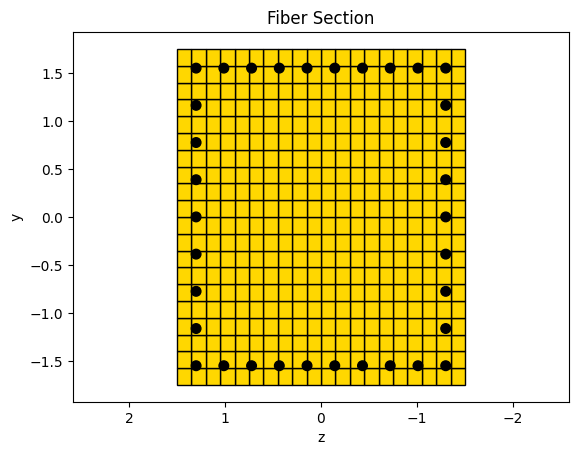

In [118]:

# some variables derived from the parameters
y1 = D/2.0
z1 = B/2.0

dy = (D-2*ed)/(Nby+1)
y2 = y1-ed-dy
secTag = 1

#ops.section(secType, secTag, *secArgs)¶
fib_sec_CFST = [['section','Fiber',secTag,'-GJ',1.0e6],
    # Create the concrete core fibers
    ['patch', 'rect', ConcMatTag, Ny, Nz, -y1, -z1, y1, z1],
    ['layer', 'straight', SteelMatTag, Nbz, Ab, y1-ed, z1-ed, y1-ed, ed-z1], # Top
    ['layer', 'straight', SteelMatTag, Nby, Ab, y2, ed-z1, -y2, ed-z1], # Right column
    ['layer', 'straight', SteelMatTag, Nbz, Ab, ed-y1, ed-z1, ed-y1, z1-ed], # Bottom
    ['layer', 'straight', SteelMatTag, Nby, Ab, -y2, z1-ed, y2, z1-ed] # Left column
    ]

matcolor = ['gold','lightgrey', 'gold', 'm', 'r', 'w', 'w']
print(fib_sec_CFST)
opsv.plot_fiber_section(fib_sec_CFST, matcolor=matcolor)
plt.axis('equal')
plt.title('Fiber Section')
plt.savefig('fiber_section.png')


In [119]:
opsv.fib_sec_list_to_cmds(fib_sec_CFST)


In [120]:
# Define element
#                             tag ndI ndJ  secTag
ops.element('zeroLengthSection',  1,   1,   2,  secTag)

#%% Record stress-strain response in bolts and get bolt forces
def get_straight_layer_coords(n_fibers, yI, zI, yJ, zJ):
    ys = np.linspace(yI, yJ, n_fibers)
    zs = np.linspace(zI, zJ, n_fibers)
    return list(zip(ys, zs))

# Define all steel fiber layers
steel_fiber_coords = []

# Top bolt column
steel_fiber_coords += get_straight_layer_coords(Nbz, y1-ed, z1-ed, y1-ed, ed-z1)
# Right bolt column
steel_fiber_coords += get_straight_layer_coords(Nby, y2, ed-z1, -y2, ed-z1)
# Bottom bolt column
steel_fiber_coords += get_straight_layer_coords(Nbz, ed-y1, ed-z1, ed-y1, z1-ed)
# Left bolt column
steel_fiber_coords += get_straight_layer_coords(Nby, -y2, z1-ed, y2, z1-ed)

# Print coordinates
for i, (y, z) in enumerate(steel_fiber_coords, 1):
    print(f"Steel Fiber {i}: y = {y:.3f}, z = {z:.3f}")


Steel Fiber 1: y = 1.550, z = 1.300
Steel Fiber 2: y = 1.550, z = 1.011
Steel Fiber 3: y = 1.550, z = 0.722
Steel Fiber 4: y = 1.550, z = 0.433
Steel Fiber 5: y = 1.550, z = 0.144
Steel Fiber 6: y = 1.550, z = -0.144
Steel Fiber 7: y = 1.550, z = -0.433
Steel Fiber 8: y = 1.550, z = -0.722
Steel Fiber 9: y = 1.550, z = -1.011
Steel Fiber 10: y = 1.550, z = -1.300
Steel Fiber 11: y = 1.163, z = -1.300
Steel Fiber 12: y = 0.775, z = -1.300
Steel Fiber 13: y = 0.388, z = -1.300
Steel Fiber 14: y = 0.000, z = -1.300
Steel Fiber 15: y = -0.387, z = -1.300
Steel Fiber 16: y = -0.775, z = -1.300
Steel Fiber 17: y = -1.163, z = -1.300
Steel Fiber 18: y = -1.550, z = -1.300
Steel Fiber 19: y = -1.550, z = -1.011
Steel Fiber 20: y = -1.550, z = -0.722
Steel Fiber 21: y = -1.550, z = -0.433
Steel Fiber 22: y = -1.550, z = -0.144
Steel Fiber 23: y = -1.550, z = 0.144
Steel Fiber 24: y = -1.550, z = 0.433
Steel Fiber 25: y = -1.550, z = 0.722
Steel Fiber 26: y = -1.550, z = 1.011
Steel Fiber 27: y 

In [121]:
for i, (y, z) in enumerate(steel_fiber_coords, 1):
    ops.recorder('Element', '-file', f'fiber_{i}.txt', '-ele', secTag, 'section', 'fiber', y, z, SteelMatTag,'stressStrain')

fibLoc = D/2-ed
ops.recorder('Element','-ele',1,'-file','BoltFiber.out','section','fiber', -fibLoc, 0,SteelMatTag,'stressStrain')

#%% Record bearing pressure at four corners
ops.recorder('Element','-ele',1,'-file','BearingP1.out','section','fiber', y1, z1,ConcMatTag,'stressStrain')
ops.recorder('Element','-ele',1,'-file','BearingP2.out','section','fiber', y1, -z1,ConcMatTag,'stressStrain')
ops.recorder('Element','-ele',1,'-file','BearingP3.out','section','fiber', -y1, -z1,ConcMatTag,'stressStrain')
ops.recorder('Element','-ele',1,'-file','BearingP4.out','section','fiber', -y1, z1,ConcMatTag,'stressStrain')

# Create recorders for concrete fibers set by Vishal
dy_fiber = 2 * y1 / Ny
dz_fiber = 2 * z1 / Nz
concrete_fiber_coords = []

os.makedirs('concrete_fibers', exist_ok=True)

for i in range(Ny):
    for j in range(Nz):
        y_center = -y1 + (i + 0.5) * dy_fiber
        z_center = -z1 + (j + 0.5) * dz_fiber
        concrete_fiber_coords.append((y_center, z_center))
        # Store files in directory -> concrete_fibers
        ops.recorder('Element', '-file', f'concrete_fibers/fiber_{i}_{j}.txt', 
                    '-ele', 1, 'section', 'fiber', y_center, z_center, 
                    ConcMatTag, 'stressStrain')

In [122]:

#%% Define constant axial load
ops.timeSeries('Constant', 1)
ops.pattern('Plain', 1, 1)
ops.load(2, P, 0.0, 0.0, 0.0, My, Mz)

# Define analysis parameters
ops.integrator('LoadControl', 0.0)
ops.system('SparseGeneral', '-piv')
ops.test('NormUnbalance', 1e-9, 10)
ops.numberer('Plain')
ops.constraints('Plain')
ops.algorithm('Newton')
ops.analysis('Static')

In [123]:
# Do one analysis for constant axial load
ops.analyze(1)

0

In [ ]:
print(f'Applied P = {P} N, My = {My} N·m, Mz = {Mz} N·m')
print(f'P = {P} and Mz = {Mz} applied')
# Verify section forces
forces = ops.eleForce(1)
print("\nSECTION FORCE VERIFICATION:")
print(f"  Axial (P): Applied = {P}, Section = {forces[0]}")
print(f"  Moment-Y (My): Applied = {My}, Section = {forces[4]}")
print(f"  Moment-Z (Mz): Applied = {Mz}, Section = {forces[5]}")

#%% Get forces in each bolt and write to an excel file
fiber_forces = []
bolt_stress = []
bolt_strain = []
# --- Loop through each fiber file ---
for i in range(1, Nb + 1):
    try:
        filename = f"fiber_{i}.txt"
        bolt_data = np.loadtxt(filename)  # shape: (n_steps,)
        bolt_stress.append(bolt_data[0])
        bolt_strain.append(bolt_data[1])
        force = bolt_data[0] * Ab
        fiber_forces.append(force)
    except FileNotFoundError:
        print(f"Warning: Missing bolt fiber file {i}")
        bolt_stress.append(0.0)
        bolt_strain.append(0.0)
        fiber_forces.append(0.0)

# Convert to numpy array for further processing
# shape: (num_fibers, n_steps)
fiber_forces = np.array(fiber_forces)
bolt_stress = np.array(bolt_stress)
bolt_strain = np.array(bolt_strain)

# Save bolt data
bolt_data = []
for i, (y, z) in enumerate(steel_fiber_coords):
    bolt_data.append([y, z, fiber_forces[i], bolt_stress[i], bolt_strain[i]])

df_bolts = pd.DataFrame(bolt_data, 
                        columns=['y (m)', 'z (m)', 'Force', 'Stress', 'Strain'])
df_bolts.to_excel('Bolt_Forces.xlsx', index=False)


Applied P = -46000.0 N, My = 14923 N·m, Mz = 55624 N·m
P = -46000.0 and Mz = 55624 applied

SECTION FORCE VERIFICATION:
  Axial (P): Applied = -46000.0, Section = 45999.99999999994
  Moment-Y (My): Applied = 14923, Section = -14923.000000000016
  Moment-Z (Mz): Applied = 55624, Section = -55624.000000000044


In [125]:
for e,i in enumerate(bolt_stress):
    print("each ", e+1, " Stress ", i)

each  1  Stress  0.0
each  2  Stress  0.0
each  3  Stress  0.0
each  4  Stress  0.0
each  5  Stress  0.0
each  6  Stress  0.0
each  7  Stress  0.0
each  8  Stress  0.0
each  9  Stress  0.0
each  10  Stress  0.0
each  11  Stress  0.0
each  12  Stress  0.0
each  13  Stress  0.0
each  14  Stress  0.0
each  15  Stress  0.0
each  16  Stress  0.0
each  17  Stress  8548.46
each  18  Stress  23593.5
each  19  Stress  27977.5
each  20  Stress  32361.5
each  21  Stress  36745.5
each  22  Stress  41129.5
each  23  Stress  45513.5
each  24  Stress  49897.6
each  25  Stress  54281.6
each  26  Stress  58665.6
each  27  Stress  63049.6
each  28  Stress  48004.5
each  29  Stress  32959.4
each  30  Stress  17914.4
each  31  Stress  2869.3
each  32  Stress  0.0
each  33  Stress  0.0
each  34  Stress  0.0


In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D

C:\Users\Vishal\AppData\Local\Temp\ipykernel_23688\184820259.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


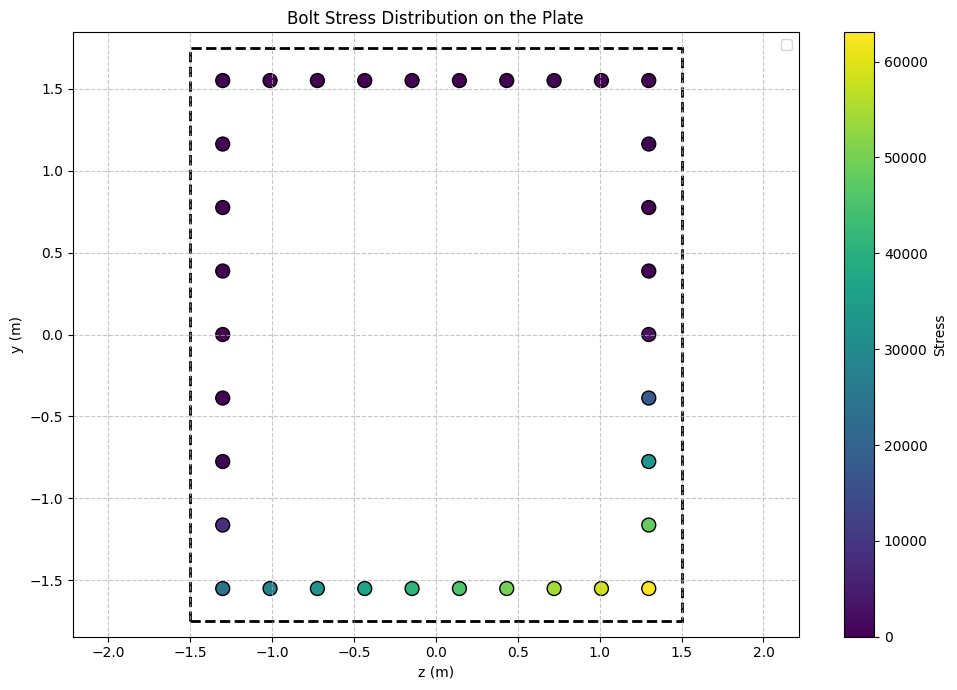

In [127]:
df = pd.read_excel('Bolt_Forces.xlsx')
y = df['y (m)']
z = df['z (m)']
stress_pa = df['Stress'] 
stress_mpa = stress_pa 
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(z, y, c=stress_mpa, cmap='viridis', s=100, edgecolor='k')
plate_rect = patches.Rectangle(
    (-1.5, -1.75), 3, 3.5,  # (x, y), width, height
    linewidth=2, edgecolor='black', facecolor='none',
    linestyle='--'
)
ax.add_patch(plate_rect)
plt.colorbar(scatter, label='Stress')
ax.set_xlabel('z (m)')
ax.set_ylabel('y (m)')
ax.set_title('Bolt Stress Distribution on the Plate')
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.8, 1.8)
ax.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# Process concrete results
concrete_stress = np.zeros((Ny, Nz))
concrete_strain = np.zeros((Ny, Nz))
y_coords = np.zeros((Ny, Nz))
z_coords = np.zeros((Ny, Nz))

for i in range(Ny):
    for j in range(Nz):
        try:
            data = np.loadtxt(f'concrete_fibers/fiber_{i}_{j}.txt')
            concrete_stress[i, j] = data[0]   # Stress
            concrete_strain[i, j] = data[1]    # Strain
        except FileNotFoundError:
            print(f"Warning: Missing concrete fiber file {i}_{j}")
            concrete_stress[i, j] = 0.0
            concrete_strain[i, j] = 0.0
 
        y_coords[i, j] = -y1 + (i + 0.5) * dy_fiber
        z_coords[i, j] = -z1 + (j + 0.5) * dz_fiber

# Save concrete data
concrete_data = []
for i in range(Ny):
    for j in range(Nz):
        concrete_data.append([
            y_coords[i, j], 
            z_coords[i, j],
            concrete_stress[i, j],
            concrete_strain[i, j]
        ])

df_concrete = pd.DataFrame(concrete_data, 
                          columns=['y (m)', 'z (m)', 'Stress', 'Strain'])
df_concrete.to_excel('Concrete_Fiber_Results.xlsx', index=False)

top_idx = np.unravel_index(np.argmax(y_coords), y_coords.shape)
bot_idx = np.unravel_index(np.argmin(y_coords), y_coords.shape)

# print("\nCONCRETE EXTREME FIBERS:")
# print(f"TOP: y={y_coords[top_idx]:.3f} m, stress={concrete_stress[top_idx]:.4f} , "
#       f"strain={concrete_strain[top_idx]:.6f}")
# print(f"BOTTOM: y={y_coords[bot_idx]:.3f} m, stress={concrete_stress[bot_idx]:.4f} , "
#       f"strain={concrete_strain[bot_idx]:.6f}")


CONCRETE EXTREME FIBERS:
TOP: y=1.662 m, stress=-18213.6000 , strain=-0.000515
BOTTOM: y=-1.663 m, stress=0.0000 , strain=0.000130


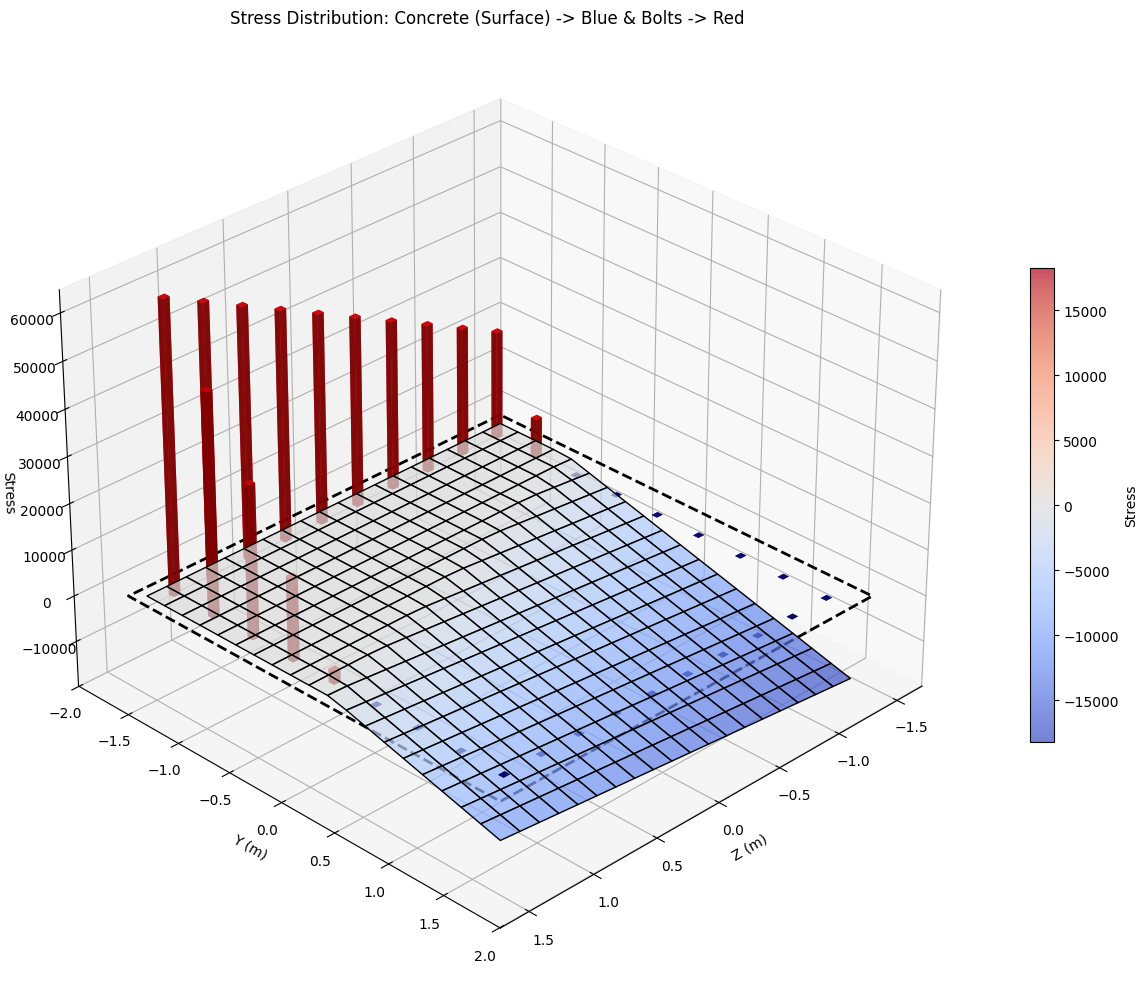

In [129]:
# Visualization of Stress Distribution
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(z_coords, y_coords, concrete_stress, cmap='coolwarm', edgecolor='black', alpha=0.7,
                      vmin=-np.max(np.abs(concrete_stress)), vmax=np.max(np.abs(concrete_stress)))
fig.colorbar(surf, ax=ax, label='Stress', shrink=0.5)

bar_width = 0.05
bar_depth = 0.05

for i, (x, y, stress) in enumerate(zip(df_bolts['z (m)'], df_bolts['y (m)'], df_bolts['Stress'])):
    ax.bar3d(x - bar_width/2, 
             y - bar_depth/2, 
             0, 
             bar_width, 
             bar_depth, 
             stress, 
             color='red' if stress > 0 else 'darkblue',
             alpha=0.8,
             shade=True)

z_min, z_max = -B/2, B/2
y_min, y_max = -D/2, D/2
ax.plot([z_min, z_max, z_max, z_min, z_min],
        [y_min, y_min, y_max, y_max, y_min],
        [0, 0, 0, 0, 0], '--', linewidth=2, color="black")
ax.set_xlabel('Z (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Stress')
ax.set_title('Stress Distribution: Concrete (Surface) -> Blue & Bolts -> Red')
ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.savefig('3d_stress_distribution.png', dpi=1000)
plt.show()

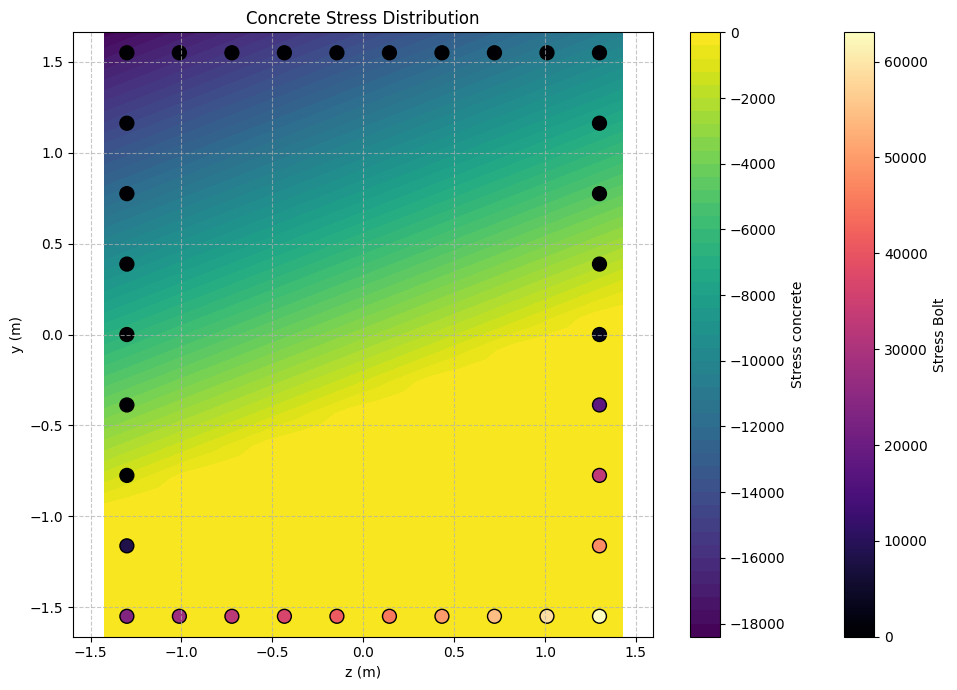

In [130]:
plt.figure(figsize=(10, 7))
contour = plt.contourf(z_coords, y_coords, concrete_stress , 50, cmap='viridis')
scatter = plt.scatter(df_bolts['z (m)'], df_bolts['y (m)'], 
                     c=df_bolts['Stress'], cmap='magma', 
                     s=100, edgecolor='k')
plt.colorbar(scatter, label='Stress Bolt')
plt.colorbar(contour, label='Stress concrete')
plt.xlabel('z (m)')
plt.ylabel('y (m)')
plt.title('Concrete Stress Distribution')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('concrete_stress_contour.png')